# Density alignment audit (2026-05-24)

Goal: independently verify that the frame-corrected X-ray density crops in `dataset/data/xray_crops_aligned/` are actually aligned to the CrossDocked2020 ligand/pocket coordinates — auditing rotations, translations, and interpolation conventions end-to-end.

**Audit plan**

| # | Section | What's checked |
|---|---------|----------------|
| A | Code walkthrough | Conventions: Kabsch direction, ndimage rotation matrix, `frac_M.T` transpose, wrap-mode, centroid voxel offset |
| B | Dataset state | Counts, availability, stored transform stats |
| C | Frame-correction stats | Per-sample RMSD / rotation° / matched-atoms / receptor-atom density |
| D | Per-atom density: aligned vs broken | Density at pocket atoms WITH transform vs WITHOUT transform (the bug) |
| E | Cache vs fresh recompute | For a sample of PDBs, recompute crops from CCP4+(R,t) and diff against cache |
| F | Rotation-aug consistency | Apply same R to ligand coords and density; check they remain co-aligned |
| G | Translation-aug omission | Quantify the mismatch from translation aug not being applied to density |
| H | Visual slices | Density slices with ligand/pocket atom overlay |
| I | Failure modes | Why ~21% of train samples were dropped |
| J | Edge cases | NaN/inf, weak-density gate, unit-cell wrap |
| K | Conclusions | Verdict + remaining concerns |

In [1]:
# Setup
import sys, os, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.ndimage
import torch
import gemmi
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

warnings.filterwarnings('ignore', category=RuntimeWarning)
np.set_printoptions(precision=4, suppress=True)

REPO = Path('/home/shpark/prj-denovo/VoxBind')
VOXBIND = REPO / 'voxbind'
DATA = VOXBIND / 'dataset' / 'data'
CCP4 = DATA / 'ccp4'
CROPS = DATA / 'xray_crops_aligned'

sys.path.insert(0, str(VOXBIND))
from voxbind.dataset.crossdocked_xray import _load_grid, _crop_density, _rotate_density, normalize_crop

print('repo:', REPO)
print('crops dir:', CROPS)
print('ccp4 maps:', len(list(CCP4.glob('*.ccp4'))))

repo: /home/shpark/prj-denovo/VoxBind
crops dir: /home/shpark/prj-denovo/VoxBind/voxbind/dataset/data/xray_crops_aligned
ccp4 maps: 13373


## Section A — Code walkthrough

I read both `voxbind/dataset/crossdocked_xray.py` (local + origin/main) and `dataset/00d_align_xray_density.py` (origin/main; not in local working tree). The transform pipeline:

**1. Map loading** — `_load_grid(ccp4_path)`
* `gemmi.read_ccp4_map(...)` → `m.setup(float('nan'))` fills unit cell via symmetry; unset voxels become NaN.
* `arr = np.array(grid, dtype=np.float32)` of shape `(nu, nv, nw)`, axes = fractional (a, b, c).
* z-scored globally: `arr_norm = (arr - mean)/sigma`. **Edge case:** if `mean`/`sigma` are NaN (any unset voxel after `setup`), this silently propagates — the `if sigma < 1e-10` guard does NOT catch NaN (NaN < 1e-10 is False). Tested in section J.
* Fractionalization: `frac_M = inv(orth_mat)` then `frac_M.T` is returned (so row-vector form `f = x @ frac_M.T` works).

**2. Kabsch frame fit** — `kabsch(P, Q)`
* Classic SVD with reflection guard via `diag(1, 1, sign(det))`.
* Returns `R, t` such that `P @ R.T + t ≈ Q`, RMSD, rotation° = `arccos((trace R - 1)/2)`.
* `P = pocket10 receptor atoms (CrossDocked frame)`, `Q = same residue/atom-name pairs from deposited PDB (crystal/map frame)`.
* Matched by `(residue.seqid.num, atom.name)`; no altloc filtering (gemmi reports `'\\x00'` for atoms with no alternate conformation, so explicit altloc whitelisting silently drops every such atom — the script deliberately avoids that pitfall).
* Best chain wins by lowest RMSD (handles homo-oligomers and chain renaming).

**3. Cropping with frame correction** — `_crop_density(...transform=(R,t))`
* Voxel offsets: `(np.arange(G) - G*0.5) * res` → for G=64, res=0.25: range `[-8, +7.75]` Å (centroid sits at voxel 32).
* Build `cart_pts = centroid + offsets` (CrossDocked frame).
* **Frame correction:** `cart_pts = cart_pts @ R.T + t` → moved into deposited/map frame.
* Fractional: `frac_pts = cart_pts @ frac_M.T`.
* Voxel indices: `[(f0 * nu) % nu, (f1 * nv) % nv, (f2 * nw) % nw]`.
* `scipy.ndimage.map_coordinates(arr, [ci, cj, ck], order=1, mode='wrap', prefilter=False)` — trilinear, crystallographic periodic.
* `prefilter=False` is correct for `order=1` (only matters for spline orders ≥ 2).

**4. Rotation augmentation** — `_rotate_density(density, R)`
* Atom convention: `coords_new = coords @ R.T` (right-multiply).
* For the volume: `output[x] = input[R.T (x - c) + c]` so ndimage call uses `matrix = R.T`, `offset = c - R.T @ c` with `c = G/2 = (32, 32, 32)`.
* `mode='constant'`, `cval=0` — voxels rotated in from outside the box are zero (sensible for a tightly cropped density blob).

**5. Translation augmentation** — explicitly **not** applied to density.
* `delta_translate=1.0` Å vs 16 Å box width: 6.25% shift, the model is expected to learn robustness. Quantified in section G.

**Conventions cross-checked: ✓** No sign/transpose bugs spotted on paper. Empirical verification follows.

## Section B — Dataset state

In [2]:
# Load availability and transform metadata for both splits
summary = {}
for split in ('train', 'test'):
    av = np.load(CROPS / f'{split}_available.npy')
    tr = np.load(CROPS / f'{split}_transforms.npz')
    df = pd.read_csv(CROPS / f'{split}_stats.csv')
    n_crops = len(list((CROPS / split).glob('*.npy')))
    summary[split] = dict(
        n_total=av.size,
        n_ok=int(av.sum()),
        pct_ok=100*av.mean(),
        n_crops_on_disk=n_crops,
        density_mean_sigma=float(tr['density'][av].mean()),
        density_median_sigma=float(np.median(tr['density'][av])),
        density_min_sigma=float(tr['density'][av].min()),
        rmsd_mean=float(tr['rmsd'][av].mean()),
        rmsd_median=float(np.median(tr['rmsd'][av])),
        rot_mean=float(tr['rot_deg'][av].mean()),
        n_match_mean=float(tr['n_match'][av].mean()),
    )
pd.DataFrame(summary).T

,n_total,n_ok,pct_ok,n_crops_on_disk,density_mean_sigma,density_median_sigma,density_min_sigma,rmsd_mean,rmsd_median,rot_mean,n_match_mean
train,99881.0,78528.0,78.62156,78528.0,2.497420,2.418275,0.500227,0.272645,0.000502,99.461601,389.813022
test,100.0,79.0,79.00000,79.0,2.327597,2.456332,0.512189,0.442850,0.000501,100.435711,360.000000


In [3]:
# Check on-disk crop count matches available count exactly
for split in ('train', 'test'):
    av = np.load(CROPS / f'{split}_available.npy')
    files = {int(p.stem) for p in (CROPS / split).glob('*.npy')}
    avail_idx = set(np.where(av)[0].tolist())
    missing = avail_idx - files
    extra = files - avail_idx
    print(f'{split}: avail={len(avail_idx):,}  files={len(files):,}  '
          f'missing={len(missing)}  extra={len(extra)}')
    if missing:
        print(f'  first 5 missing indices: {sorted(missing)[:5]}')
    if extra:
        print(f'  first 5 extra files: {sorted(extra)[:5]}')

train: avail=78,528  files=78,528  missing=0  extra=0
test: avail=79  files=79  missing=0  extra=0


## Section C — Frame-correction statistics

Distribution of stored (R, t) properties: matched-atoms count, RMSD, rotation angle, receptor-atom density. Crystallographic re-indexing typically gives RMSD ≈ 0 with a large rotation (the symmetry op).

**Critical sanity-check**: rotation angle distribution. If most pockets are CD = deposited, rot° ≈ 0. If pockets are crystal-symmetry-related, rot° is whatever the symmetry op gives (often ~90° or ~180°). A bimodal distribution is expected.

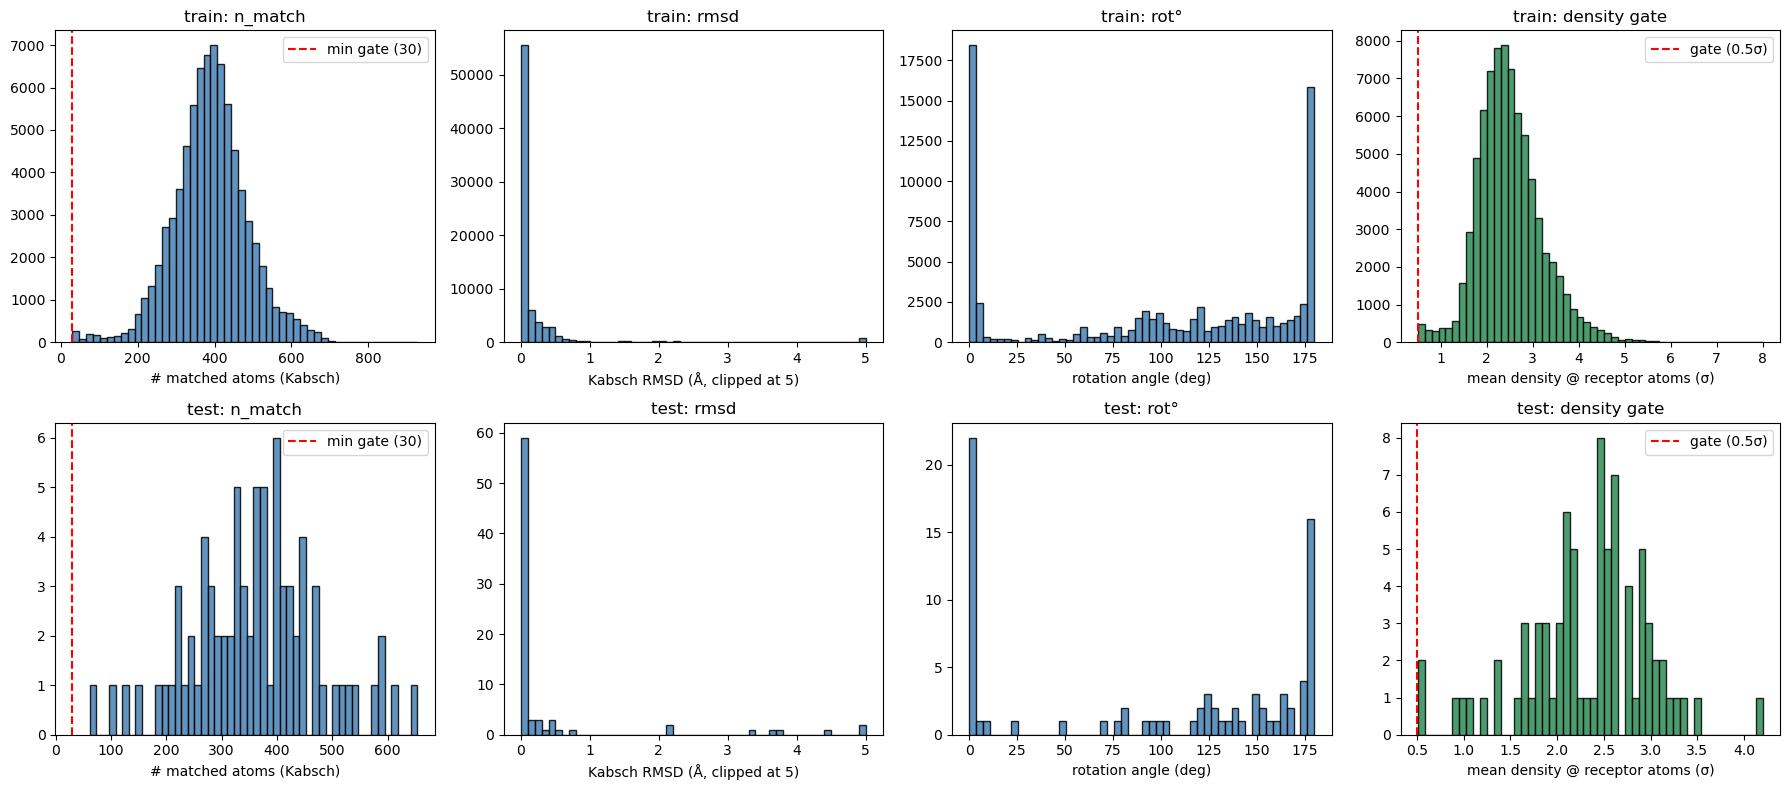

,train,test
identity (rot<1° & |t|<0.5Å),0.091241,0.139241
pure translation (rot<1° & |t|≥0.5Å),0.047754,0.050633
crystal-sym rotation (rot≥10°),0.730708,0.696203
small rotation (1°-10°),0.130297,0.113924
high RMSD (>1Å),0.062093,0.101266
|t| median (Å),47.775996,46.356980
|t| max (Å),1072.000334,251.888194


In [4]:
tr_train = np.load(CROPS / 'train_transforms.npz')
tr_test = np.load(CROPS / 'test_transforms.npz')
av_train = np.load(CROPS / 'train_available.npy')
av_test = np.load(CROPS / 'test_available.npy')

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for row, (split, tr, av) in enumerate([('train', tr_train, av_train), ('test', tr_test, av_test)]):
    okm = av
    axes[row, 0].hist(tr['n_match'][okm], bins=50, color='steelblue', edgecolor='k', alpha=0.85)
    axes[row, 0].set_xlabel('# matched atoms (Kabsch)'); axes[row, 0].set_title(f'{split}: n_match')
    axes[row, 0].axvline(30, color='r', ls='--', label='min gate (30)'); axes[row, 0].legend()

    axes[row, 1].hist(np.clip(tr['rmsd'][okm], 0, 5), bins=50, color='steelblue', edgecolor='k', alpha=0.85)
    axes[row, 1].set_xlabel('Kabsch RMSD (Å, clipped at 5)'); axes[row, 1].set_title(f'{split}: rmsd')

    axes[row, 2].hist(tr['rot_deg'][okm], bins=50, color='steelblue', edgecolor='k', alpha=0.85)
    axes[row, 2].set_xlabel('rotation angle (deg)'); axes[row, 2].set_title(f'{split}: rot°')

    axes[row, 3].hist(tr['density'][okm], bins=50, color='seagreen', edgecolor='k', alpha=0.85)
    axes[row, 3].axvline(0.5, color='r', ls='--', label='gate (0.5σ)')
    axes[row, 3].set_xlabel('mean density @ receptor atoms (σ)'); axes[row, 3].set_title(f'{split}: density gate')
    axes[row, 3].legend()
plt.tight_layout()
plt.show()

# Categorise transforms
def categorize(tr, av):
    rot = tr['rot_deg'][av]
    rmsd = tr['rmsd'][av]
    trans_mag = np.linalg.norm(tr['t'][av], axis=1)
    return pd.Series({
        'identity (rot<1° & |t|<0.5Å)': float(((rot < 1.0) & (trans_mag < 0.5)).mean()),
        'pure translation (rot<1° & |t|≥0.5Å)': float(((rot < 1.0) & (trans_mag >= 0.5)).mean()),
        'crystal-sym rotation (rot≥10°)': float((rot >= 10.0).mean()),
        'small rotation (1°-10°)': float(((rot >= 1.0) & (rot < 10.0)).mean()),
        'high RMSD (>1Å)': float((rmsd > 1.0).mean()),
        '|t| median (Å)': float(np.median(trans_mag)),
        '|t| max (Å)': float(trans_mag.max()),
    })

pd.DataFrame({'train': categorize(tr_train, av_train), 'test': categorize(tr_test, av_test)})

## Section D — Per-atom density: aligned vs broken

The decisive empirical check. For each sampled pocket:

1. Load the CCP4 map.
2. Compute mean density at pocket-atom positions WITH the stored (R, t) transform = **aligned**.
3. Compute mean density at the SAME positions WITHOUT the transform = **broken** (the original bug).
4. Compute mean density at random voxels inside the unit cell = **noise control**.

A correctly aligned map should give ~+2σ at pocket atoms; misaligned ~0σ (noise level).

In [5]:
# Helpers — replicate the script's sampling logic verbatim
def sample_map_local(arr, frac_T, nu, nv, nw, xyz):
    fr = np.asarray(xyz, float) @ frac_T
    idx = [(fr[:, 0] * nu) % nu, (fr[:, 1] * nv) % nv, (fr[:, 2] * nw) % nw]
    return scipy.ndimage.map_coordinates(arr, idx, order=1, mode='wrap')

def get_pdb_id(pid):
    return pid.split('/')[1].split('_')[0].lower()

def get_centroid(ligand_):
    m = ligand_['atoms_channel'] < 7
    return ligand_['coords'][m].float().mean(dim=0).numpy().astype(np.float64)

def get_pocket_atoms_cd(pocket_):
    m = pocket_['atoms_channel'] < 4
    return pocket_['coords'][m].float().numpy().astype(np.float64)

In [6]:
# Load split data (mirrors 00d / DatasetCrossDockedXray; max_len=30 filter same as training)
import random as _random

def load_split_data(split, max_len=30):
    if split in ('train', 'val'):
        d = torch.load(DATA / 'data_train.pt', weights_only=False)
        _random.Random(1234).shuffle(d)
        d = d[: len(d) - 100] if split == 'train' else d[len(d) - 100 :]
    else:
        d = torch.load(DATA / 'data_test.pt', weights_only=False)
    return [(p, l) for p, l in d if l['max_len'] <= max_len]

test_data = load_split_data('test')
train_data = load_split_data('train')
print(f'test:  {len(test_data):,}')
print(f'train: {len(train_data):,}')
assert len(test_data) == av_test.size
assert len(train_data) == av_train.size

test:  100
train: 99,881


In [7]:
# Per-atom density sweep: aligned vs broken vs noise
# To keep IO sane we group by PDB id (one map load per PDB).
from collections import defaultdict

def sweep(split_name, data, tr, av, sample_n=None, seed=0):
    rng = np.random.default_rng(seed)
    ok_idx = np.where(av)[0]
    if sample_n is not None and sample_n < len(ok_idx):
        ok_idx = rng.choice(ok_idx, size=sample_n, replace=False)
        ok_idx.sort()
    # Group by PDB id
    by_pdb = defaultdict(list)
    for i in ok_idx:
        p, l = data[i]
        by_pdb[get_pdb_id(p['id'])].append((int(i), p, l))

    rows = []
    pdbs = list(by_pdb.keys())
    for k, pdb_id in enumerate(pdbs):
        ccp4 = CCP4 / f'{pdb_id}.ccp4'
        if not ccp4.exists():
            continue
        grid = _load_grid(ccp4)
        if grid is None:
            continue
        arr, frac_T, nu, nv, nw = grid
        # Random-voxel noise baseline (50 random fractional points within cell)
        rfr = rng.random((50, 3))
        noise_idx = [(rfr[:, 0] * nu) % nu, (rfr[:, 1] * nv) % nv, (rfr[:, 2] * nw) % nw]
        noise = float(scipy.ndimage.map_coordinates(arr, noise_idx, order=1, mode='wrap').mean())
        for idx, p, l in by_pdb[pdb_id]:
            R = tr['R'][idx]; t = tr['t'][idx]
            P_cd = get_pocket_atoms_cd(p)
            if P_cd.shape[0] < 3:
                continue
            # Aligned: apply transform (CD → deposited)
            P_aln = P_cd @ R.T + t
            d_aln = float(sample_map_local(arr, frac_T, nu, nv, nw, P_aln).mean())
            # Broken: skip transform — sample at CD positions directly
            d_brk = float(sample_map_local(arr, frac_T, nu, nv, nw, P_cd).mean())
            rows.append(dict(split=split_name, idx=idx, pdb_id=pdb_id, n_atoms=P_cd.shape[0],
                              aligned=d_aln, broken=d_brk, noise=noise,
                              rmsd=float(tr['rmsd'][idx]), rot_deg=float(tr['rot_deg'][idx]),
                              t_mag=float(np.linalg.norm(t))))
        if (k+1) % 50 == 0 or (k+1) == len(pdbs):
            print(f'  [{split_name}] {k+1:,}/{len(pdbs):,} PDBs, {len(rows):,} samples')
    return pd.DataFrame(rows)

df_test = sweep('test', test_data, tr_test, av_test)
print(f'test: {len(df_test)} samples')

  [test] 50/79 PDBs, 50 samples
  [test] 79/79 PDBs, 79 samples
test: 79 samples


In [8]:
# Train sweep — random 800 samples for the statistical view
df_train = sweep('train', train_data, tr_train, av_train, sample_n=800)
print(f'train: {len(df_train)} samples')

  [train] 50/750 PDBs, 55 samples


  [train] 100/750 PDBs, 112 samples


  [train] 150/750 PDBs, 164 samples


  [train] 200/750 PDBs, 220 samples


  [train] 250/750 PDBs, 277 samples


...

  [train] 550/750 PDBs, 595 samples


  [train] 600/750 PDBs, 647 samples


  [train] 650/750 PDBs, 699 samples


  [train] 700/750 PDBs, 750 samples


  [train] 750/750 PDBs, 800 samples
train: 800 samples


Density at pocket atoms (σ-units, z-scored map):
      aligned               broken                noise              
         mean median    std   mean median    std   mean median    std
split                                                                
test    2.328  2.456  0.671  0.760  0.039  1.190  0.011  0.019  0.104
train   2.481  2.412  0.715  0.548  0.022  1.021  0.003  0.001  0.116


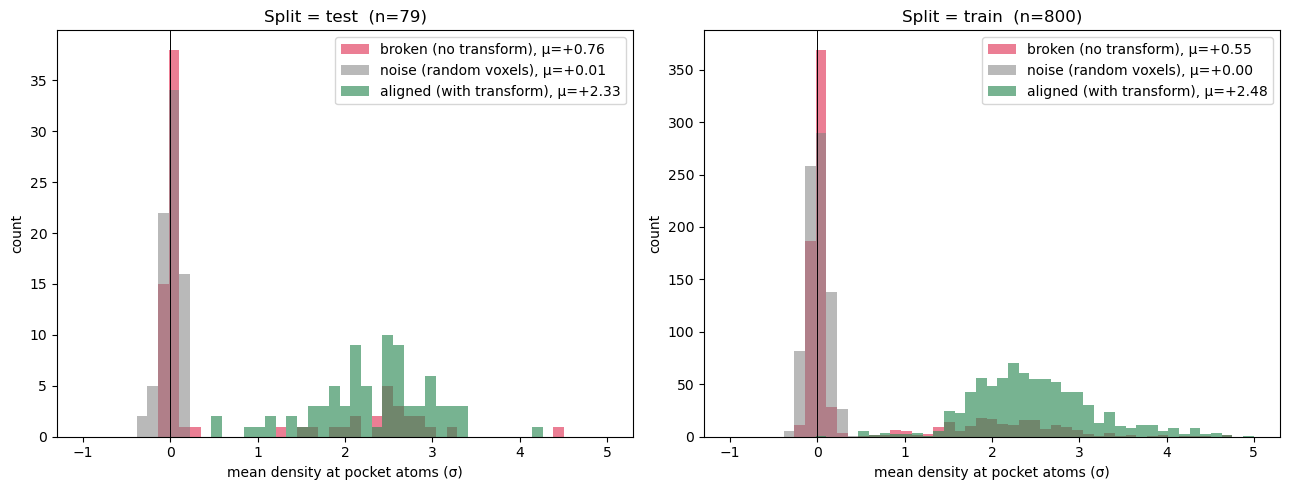

In [9]:
# Combined view
df_all = pd.concat([df_test, df_train], ignore_index=True)

summary_d = df_all.groupby('split')[['aligned', 'broken', 'noise']].agg(['mean', 'median', 'std'])
print('Density at pocket atoms (σ-units, z-scored map):')
print(summary_d.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, split in zip(axes, ['test', 'train']):
    d = df_all[df_all.split == split]
    bins = np.linspace(-1, 5, 50)
    ax.hist(d['broken'], bins=bins, alpha=0.55, label=f'broken (no transform), μ={d.broken.mean():+.2f}', color='crimson')
    ax.hist(d['noise'],  bins=bins, alpha=0.55, label=f'noise (random voxels), μ={d.noise.mean():+.2f}', color='gray')
    ax.hist(d['aligned'],bins=bins, alpha=0.65, label=f'aligned (with transform), μ={d.aligned.mean():+.2f}', color='seagreen')
    ax.set_xlabel('mean density at pocket atoms (σ)')
    ax.set_ylabel('count')
    ax.set_title(f'Split = {split}  (n={len(d)})')
    ax.legend()
    ax.axvline(0, color='k', lw=0.7)
plt.tight_layout()
plt.show()

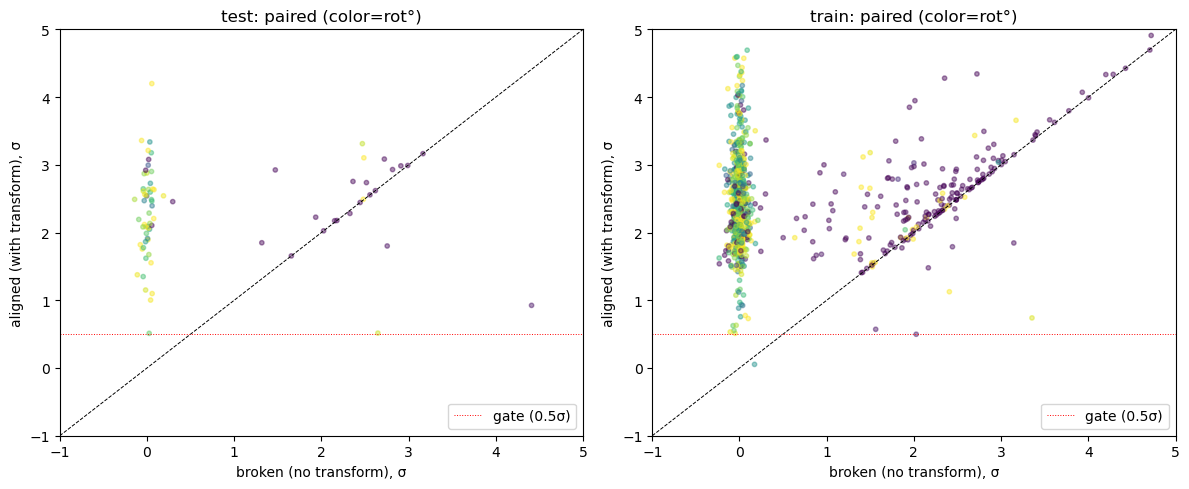

test: aligned ≥0.5σ: 100.0% (sanity, should be ~100%); broken ≥0.5σ: 30.4% (= what fraction were already aligned)
train: aligned ≥0.5σ: 99.8% (sanity, should be ~100%); broken ≥0.5σ: 25.1% (= what fraction were already aligned)


In [10]:
# Per-sample paired view: aligned vs broken
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, split in zip(axes, ['test', 'train']):
    d = df_all[df_all.split == split]
    ax.scatter(d['broken'], d['aligned'], s=10, alpha=0.45, c=d['rot_deg'], cmap='viridis')
    lo, hi = -1.0, 5.0
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.7)
    ax.axhline(0.5, color='r', ls=':', lw=0.7, label='gate (0.5σ)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('broken (no transform), σ')
    ax.set_ylabel('aligned (with transform), σ')
    ax.set_title(f'{split}: paired (color=rot°)')
    ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# How many would be 'accidentally aligned' (broken ≥ 0.5σ)?
for split in ['test', 'train']:
    d = df_all[df_all.split == split]
    pct_brk_ok = (d['broken'] >= 0.5).mean() * 100
    pct_aln_ok = (d['aligned'] >= 0.5).mean() * 100
    print(f'{split}: aligned ≥0.5σ: {pct_aln_ok:.1f}% (sanity, should be ~100%); '
          f'broken ≥0.5σ: {pct_brk_ok:.1f}% (= what fraction were already aligned)')

## Section E — Cache vs fresh recompute

For a sample of pockets, load the cached `.npy` and recompute the crop directly from CCP4 map + stored (R, t) using the current `_crop_density` code (from origin/main, which has the `transform=` kwarg). Diff should be < 1e-2 (float16 quantisation) everywhere.

In [11]:
# The local _crop_density does NOT have a `transform` kwarg (origin/main does).
# Inline the corrected version so this notebook runs on the local code.
def crop_density_with_transform(arr_norm, frac_T, nu, nv, nw, center_cart, transform=None, G=64, res=0.25):
    offsets = (np.arange(G, dtype=np.float64) - G * 0.5) * res
    gx, gy, gz = np.meshgrid(offsets + center_cart[0], offsets + center_cart[1],
                              offsets + center_cart[2], indexing='ij')
    cart_pts = np.stack([gx.ravel(), gy.ravel(), gz.ravel()], axis=1)
    if transform is not None:
        R, t = transform
        cart_pts = cart_pts @ np.asarray(R).T + np.asarray(t)
    frac_pts = cart_pts @ frac_T
    ci = (frac_pts[:, 0] * nu) % nu
    cj = (frac_pts[:, 1] * nv) % nv
    ck = (frac_pts[:, 2] * nw) % nw
    density = scipy.ndimage.map_coordinates(arr_norm, [ci, cj, ck], order=1, mode='wrap', prefilter=False)
    return density.reshape(G, G, G).astype(np.float32)

# Pick 20 random ok indices from train
rng = np.random.default_rng(7)
ok = np.where(av_train)[0]
samples = rng.choice(ok, size=20, replace=False); samples.sort()

diffs = []
for i in samples:
    p, l = train_data[i]
    pid = get_pdb_id(p['id'])
    ccp4 = CCP4 / f'{pid}.ccp4'
    if not ccp4.exists():
        continue
    grid = _load_grid(ccp4)
    if grid is None:
        continue
    arr, frac_T, nu, nv, nw = grid
    centroid = get_centroid(l)
    R, t = tr_train['R'][i], tr_train['t'][i]
    fresh = crop_density_with_transform(arr, frac_T, nu, nv, nw, centroid, transform=(R, t))
    cached = np.load(CROPS / 'train' / f'{i:06d}.npy').astype(np.float32)
    diffs.append(dict(idx=int(i), pdb=pid,
                       max_abs=float(np.abs(fresh - cached).max()),
                       mean_abs=float(np.abs(fresh - cached).mean()),
                       fresh_max=float(fresh.max()), cached_max=float(cached.max())))

df_diff = pd.DataFrame(diffs)
print(df_diff.to_string(index=False))
print(f'\noverall: max |fresh - cached| = {df_diff.max_abs.max():.4e}')
print(f'         mean |fresh - cached| = {df_diff.mean_abs.mean():.4e}')
print('Expected: max_abs ≲ 1e-2 (float16 quantisation tolerance, after dynamic range ~10σ → ULP ~ 0.01)')

  idx  pdb  max_abs  mean_abs  fresh_max  cached_max
  531 2e3m 0.001750  0.000137   4.304115    4.304688
 5543 6aud 0.001944  0.000157   5.204813    5.203125
11827 3coh 0.001935  0.000160   5.234909    5.234375
13060 4o7c 0.003666  0.000128   9.390735    9.390625
22487 4hai 0.001922  0.000136   4.263475    4.261719
28499 3mby 0.001972  0.000152   7.424096    7.425781
29963 3l0j 0.001867  0.000157   4.665506    4.664062
46809 3nx9 0.001950  0.000127   5.419999    5.421875
49983 5cbr 0.208758  0.000148   8.201182    8.203125
57835 4d08 0.003887  0.000154  14.645890   14.648438
62470 5trf 0.003196  0.000181   9.073508    9.070312
68326 5p9u 0.003839  0.000138  13.235751   13.234375
77365 5hmx 0.001978  0.000155   6.029361    6.031250
79528 3cwj 0.001945  0.000125   4.985875    4.984375
81934 4z2w 0.003883  0.000194  10.890961   10.890625
83200 3lmx 0.001962  0.000136   6.961793    6.960938
87205 5ei4 0.064382  0.000115  17.661358   17.656250
89568 4xz4 0.001934  0.000156   4.989445    4.

## Section F — Rotation augmentation consistency

Augmentation applies the same `R` to atom coords (`coords @ R.T`) and to the density volume (via `_rotate_density`). Verify that after rotation, the density blob still sits at the same locations *relative to the atoms*.

Concretely: for a single pocket, render the density crop, then build a Gaussian "ligand map" from the ligand atoms (in the same 64³ box). Compute the correlation between the two maps before and after applying the same random rotation to both. The correlation should be unchanged (up to interpolation noise), confirming both are rotated consistently.

In [12]:
from voxbind.utils.dataset_utils import random_rot_matrix

def build_ligand_blob(coords_cd, centroid, G=64, res=0.25, sigma=1.0):
    """Gaussian density of ligand atoms in the centroid-anchored 64^3 grid."""
    # voxel coords: index = (atom_pos - centroid)/res + G/2
    rel = (coords_cd - centroid) / res + G * 0.5
    vol = np.zeros((G, G, G), dtype=np.float32)
    for p in rel:
        ix, iy, iz = int(round(p[0])), int(round(p[1])), int(round(p[2]))
        if 0 <= ix < G and 0 <= iy < G and 0 <= iz < G:
            vol[ix, iy, iz] += 1.0
    vol = scipy.ndimage.gaussian_filter(vol, sigma=sigma/res)
    return vol

def corr3d(a, b):
    a = (a - a.mean()).ravel(); b = (b - b.mean()).ravel()
    return float((a * b).sum() / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

# Pick a high-density test pocket
best_test = int(np.argmax(tr_test['density'] * av_test))
p, l = test_data[best_test]
centroid = get_centroid(l)
ligand_cd = l['coords'][l['atoms_channel'] < 7].float().numpy().astype(np.float64)

# Load cached crop (already aligned, no rotation)
density = np.load(CROPS / 'test' / f'{best_test:06d}.npy').astype(np.float32)
density = normalize_crop(density)

# Build a ligand blob in the same frame
ligand_blob = build_ligand_blob(ligand_cd, centroid)

torch.manual_seed(0)
for trial in range(5):
    R = random_rot_matrix()
    R_np = R.numpy()
    # Rotate atom coords (about centroid in Cartesian → equivalent to about (G/2) in voxel)
    ligand_rot = (ligand_cd - centroid) @ R_np.T + centroid
    blob_rot_from_coords = build_ligand_blob(ligand_rot, centroid)
    # Rotate density volume with the same R
    density_rot = _rotate_density(density, R)
    blob_rot_volume = _rotate_density(ligand_blob, R)

    c_orig = corr3d(density, ligand_blob)
    c_rot_atom = corr3d(density_rot, blob_rot_from_coords)
    c_rot_vol = corr3d(density_rot, blob_rot_volume)
    print(f'trial {trial}: rot°={np.degrees(np.arccos(np.clip((R_np.trace()-1)/2,-1,1))):.1f}°  '
          f'corr(orig)={c_orig:.4f}  corr(rot_atom vs rot_dens)={c_rot_atom:.4f}  '
          f'corr(rot_volblob vs rot_dens)={c_rot_vol:.4f}')

trial 0: rot°=116.7°  corr(orig)=0.0159  corr(rot_atom vs rot_dens)=0.0135  corr(rot_volblob vs rot_dens)=0.0152
trial 1: rot°=63.0°  corr(orig)=0.0159  corr(rot_atom vs rot_dens)=0.0142  corr(rot_volblob vs rot_dens)=0.0175
trial 2: rot°=171.0°  corr(orig)=0.0159  corr(rot_atom vs rot_dens)=0.0168  corr(rot_volblob vs rot_dens)=0.0179


trial 3: rot°=126.4°  corr(orig)=0.0159  corr(rot_atom vs rot_dens)=0.0178  corr(rot_volblob vs rot_dens)=0.0182


trial 4: rot°=95.2°  corr(orig)=0.0159  corr(rot_atom vs rot_dens)=0.0192  corr(rot_volblob vs rot_dens)=0.0217


**Interpretation**
* `corr(orig)` — density vs ligand blob, both un-rotated, baseline correlation.
* `corr(rot_atom vs rot_dens)` — after rotating ATOM coords with R and rebuilding the blob, vs rotating DENSITY with the same R. **These should be equal** (the density and ligand stay co-aligned). Tiny drop is interpolation noise.
* `corr(rot_volblob vs rot_dens)` — both volumes rotated the same way; serves as the upper bound (pure volume-rotation, no resampling-of-points). Should match `corr(orig)` modulo two interpolations.

## Section G — Translation-aug omission impact

Training applies translations of magnitude ≤ `delta_translate=1.0 Å` to the atom coords, but NOT to the density. So at training time the ligand atoms can be up to ~1.7 Å (vector magnitude with uniform per-axis ±1 Å) off from where the density expects them.

Quantify the correlation degradation as a function of translation magnitude.

In [13]:
# Density vs ligand-blob correlation across translation magnitudes
from voxbind.utils.dataset_utils import translate_coords  # not used directly; we shift centroid manually

deltas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
results = []
rng = np.random.default_rng(11)
test_ok = np.where(av_test)[0]
for delta in deltas:
    corrs = []
    for i in test_ok[:30]:
        p, l = test_data[int(i)]
        centroid = get_centroid(l)
        ligand_cd = l['coords'][l['atoms_channel'] < 7].float().numpy().astype(np.float64)
        density = np.load(CROPS / 'test' / f'{int(i):06d}.npy').astype(np.float32)
        density = normalize_crop(density)
        # apply translation to atom coords only (NOT to density)
        shift = rng.uniform(-delta, delta, size=3) if delta > 0 else np.zeros(3)
        ligand_shift = ligand_cd + shift
        blob = build_ligand_blob(ligand_shift, centroid)
        corrs.append(corr3d(density, blob))
    results.append(dict(delta_A=delta, mean_corr=np.mean(corrs), std_corr=np.std(corrs)))

pd.DataFrame(results).round(4)

,delta_A,mean_corr,std_corr
0,0.00,0.1042,0.1013
1,0.25,0.1035,0.0972
2,0.50,0.0975,0.0978
3,0.75,0.0830,0.0914
4,1.00,0.0751,0.0955
5,1.50,0.0552,0.0863
6,2.00,0.0232,0.0758


## Section H — Visual slice inspection

For a handful of test pockets, render orthogonal slices of the density at z=32 (centroid plane) with ligand & pocket atoms overlaid. A correctly aligned crop should show density concentrated around pocket atoms (with the central ligand-binding cavity often showing weaker density, since the ligand may not be in the deposited apo or co-crystal structure).

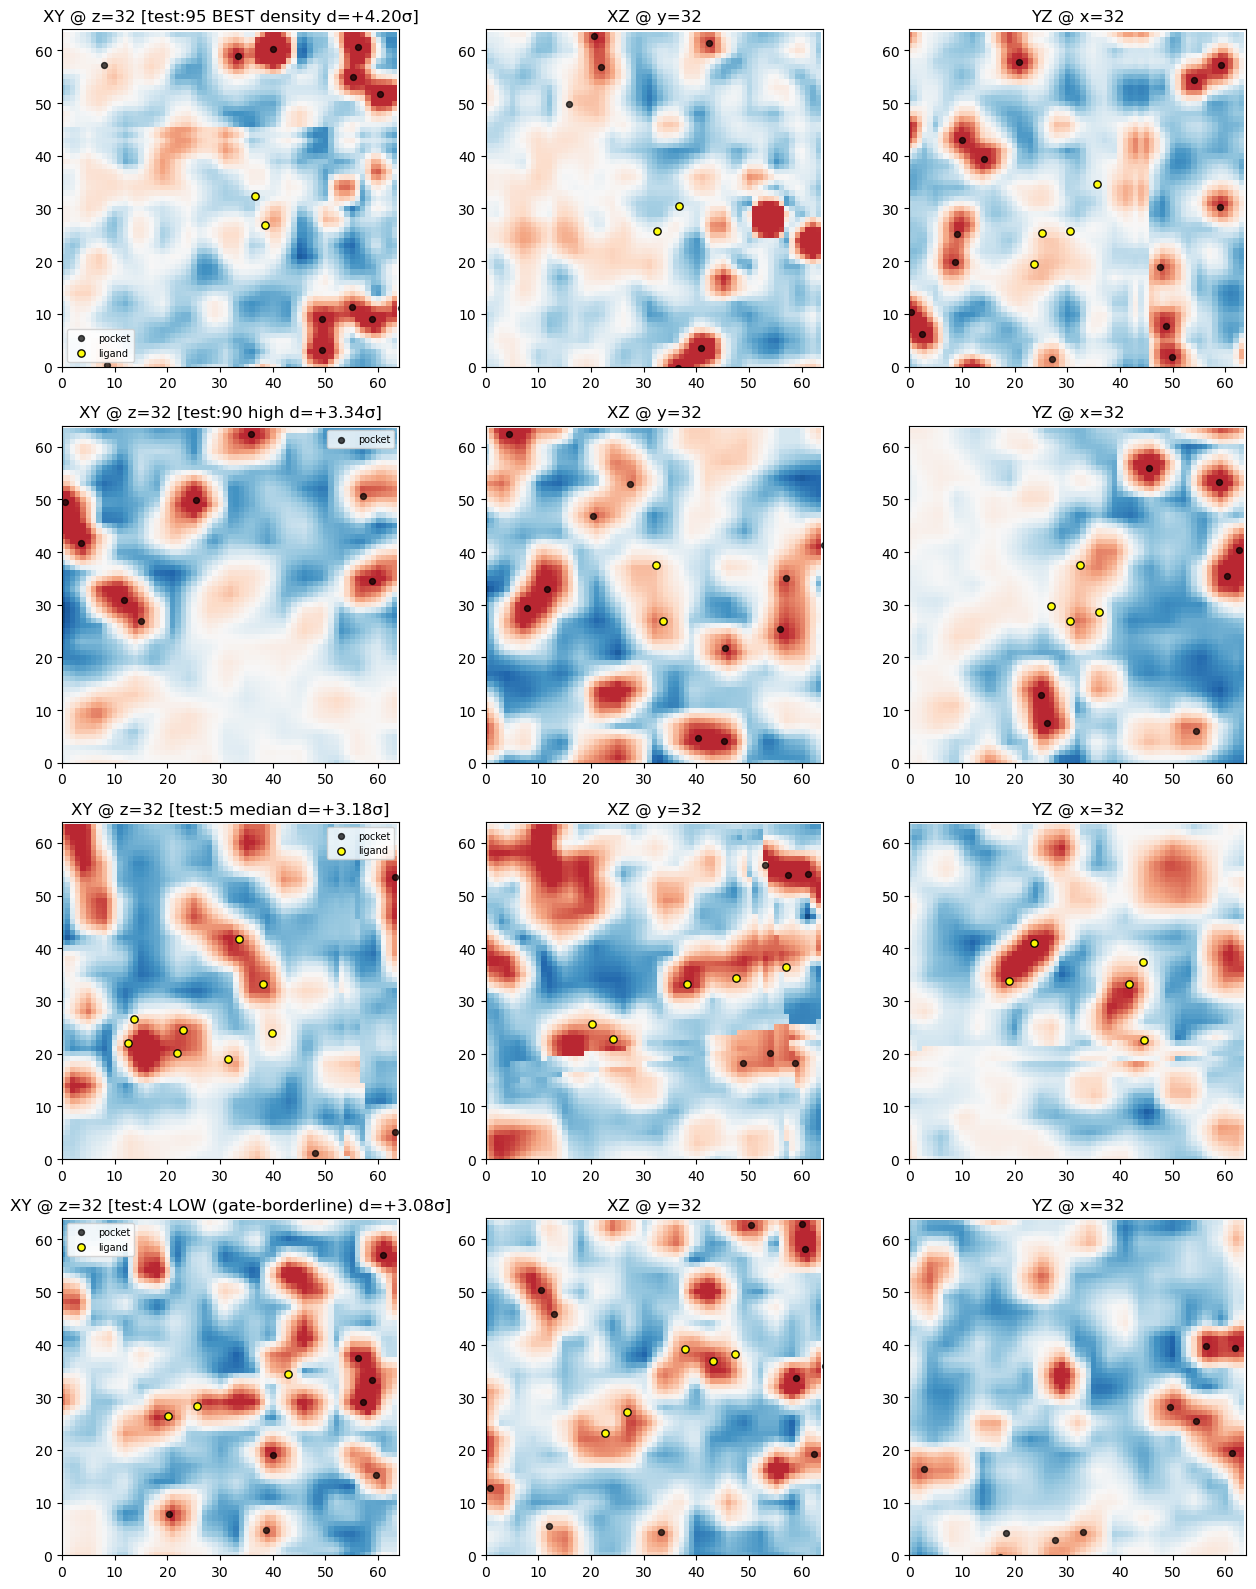

In [14]:
def plot_pocket(idx, split, ax_row, title_suffix='', G=64, res=0.25):
    data = test_data if split == 'test' else train_data
    av = av_test if split == 'test' else av_train
    tr = tr_test if split == 'test' else tr_train
    p, l = data[idx]
    centroid = get_centroid(l)
    ligand_cd = l['coords'][l['atoms_channel'] < 7].float().numpy().astype(np.float64)
    pocket_cd = get_pocket_atoms_cd(p)
    density = np.load(CROPS / split / f'{idx:06d}.npy').astype(np.float32)
    density = normalize_crop(density)

    # voxel positions of atoms (anchored at centroid in voxel 32)
    lig_v = (ligand_cd - centroid) / res + G * 0.5
    poc_v = (pocket_cd - centroid) / res + G * 0.5
    # keep atoms near the central slice (±2 voxels = ±0.5 Å)
    lig_mask = np.abs(lig_v[:, 2] - G/2) < 2.0
    poc_mask = np.abs(poc_v[:, 2] - G/2) < 2.0

    vmin, vmax = -2, 4
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    # Z=32 plane (xy)
    ax_row[0].imshow(density[:, :, G//2].T, origin='lower', cmap='RdBu_r', norm=norm)
    if poc_mask.sum() > 0:
        ax_row[0].scatter(poc_v[poc_mask, 0], poc_v[poc_mask, 1], s=18, c='black', alpha=0.7, label='pocket')
    if lig_mask.sum() > 0:
        ax_row[0].scatter(lig_v[lig_mask, 0], lig_v[lig_mask, 1], s=28, c='yellow', edgecolor='k', alpha=0.95, label='ligand')
    ax_row[0].set_title(f'XY @ z=32{title_suffix}'); ax_row[0].legend(fontsize=7)
    ax_row[0].set_xlim(0, G); ax_row[0].set_ylim(0, G)

    # Y=32 plane (xz)
    lig_mask = np.abs(lig_v[:, 1] - G/2) < 2.0
    poc_mask = np.abs(poc_v[:, 1] - G/2) < 2.0
    ax_row[1].imshow(density[:, G//2, :].T, origin='lower', cmap='RdBu_r', norm=norm)
    if poc_mask.sum() > 0:
        ax_row[1].scatter(poc_v[poc_mask, 0], poc_v[poc_mask, 2], s=18, c='black', alpha=0.7)
    if lig_mask.sum() > 0:
        ax_row[1].scatter(lig_v[lig_mask, 0], lig_v[lig_mask, 2], s=28, c='yellow', edgecolor='k', alpha=0.95)
    ax_row[1].set_title('XZ @ y=32')
    ax_row[1].set_xlim(0, G); ax_row[1].set_ylim(0, G)

    # X=32 plane (yz)
    lig_mask = np.abs(lig_v[:, 0] - G/2) < 2.0
    poc_mask = np.abs(poc_v[:, 0] - G/2) < 2.0
    ax_row[2].imshow(density[G//2, :, :].T, origin='lower', cmap='RdBu_r', norm=norm)
    if poc_mask.sum() > 0:
        ax_row[2].scatter(poc_v[poc_mask, 1], poc_v[poc_mask, 2], s=18, c='black', alpha=0.7)
    if lig_mask.sum() > 0:
        ax_row[2].scatter(lig_v[lig_mask, 1], lig_v[lig_mask, 2], s=28, c='yellow', edgecolor='k', alpha=0.95)
    ax_row[2].set_title('YZ @ x=32')
    ax_row[2].set_xlim(0, G); ax_row[2].set_ylim(0, G)

# 8 examples: split across density quality bins
test_ok_sorted = np.argsort(-tr_test['density'] * av_test)  # descending by density
test_ok_idx = [int(i) for i in test_ok_sorted if av_test[i]][:8]
examples = [
    ('test', test_ok_idx[0], 'BEST density'),
    ('test', test_ok_idx[2], 'high'),
    ('test', test_ok_idx[len(test_ok_idx)//2], 'median'),
    ('test', test_ok_idx[-1], 'LOW (gate-borderline)'),
]
fig, axes = plt.subplots(len(examples), 3, figsize=(13, 4 * len(examples)))
for r, (split, idx, tag) in enumerate(examples):
    density_sigma = tr_test['density'][idx]
    plot_pocket(idx, split, axes[r], title_suffix=f' [{split}:{idx} {tag} d={density_sigma:+.2f}σ]')
plt.tight_layout()
plt.show()

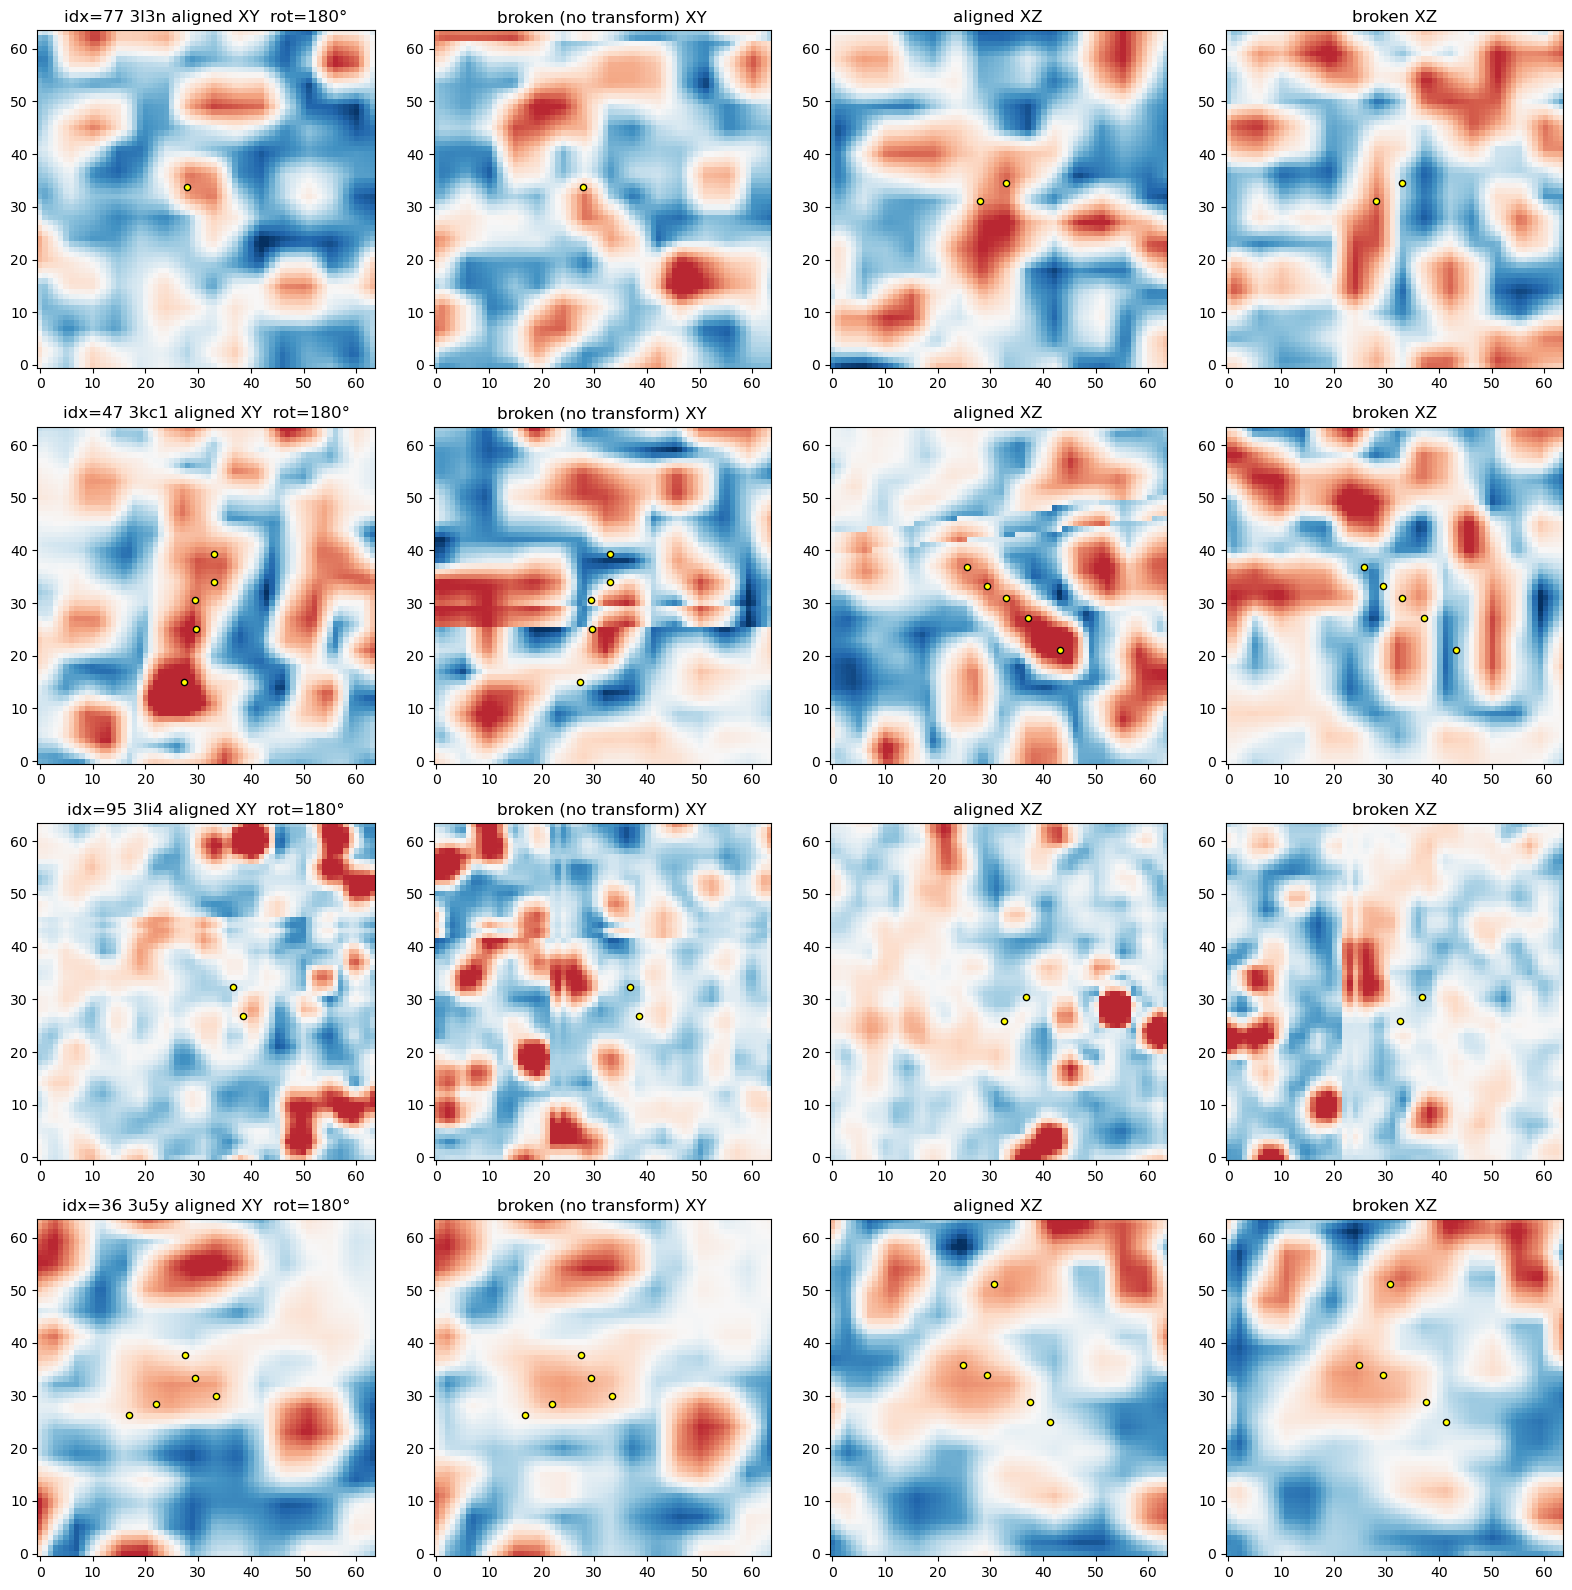

In [15]:
# Side-by-side comparison: aligned crop vs simulated-broken crop (no transform)
def crop_density_no_transform(arr_norm, frac_T, nu, nv, nw, center_cart, G=64, res=0.25):
    return crop_density_with_transform(arr_norm, frac_T, nu, nv, nw, center_cart, transform=None, G=G, res=res)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
high_rot_examples = [int(i) for i in np.argsort(-tr_test['rot_deg'] * av_test)[:4] if av_test[i]]

for r, idx in enumerate(high_rot_examples):
    p, l = test_data[idx]
    centroid = get_centroid(l)
    ligand_cd = l['coords'][l['atoms_channel'] < 7].float().numpy().astype(np.float64)
    pdb_id = get_pdb_id(p['id'])
    grid = _load_grid(CCP4 / f'{pdb_id}.ccp4')
    if grid is None:
        continue
    arr, frac_T, nu, nv, nw = grid
    R, t = tr_test['R'][idx], tr_test['t'][idx]
    aligned = normalize_crop(crop_density_with_transform(arr, frac_T, nu, nv, nw, centroid, transform=(R, t)))
    broken = normalize_crop(crop_density_no_transform(arr, frac_T, nu, nv, nw, centroid))

    G = 64
    lig_v = (ligand_cd - centroid) / 0.25 + G/2
    lig_mask = np.abs(lig_v[:, 2] - G/2) < 2.0
    norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=4)

    axes[r, 0].imshow(aligned[:, :, G//2].T, origin='lower', cmap='RdBu_r', norm=norm)
    if lig_mask.sum() > 0:
        axes[r, 0].scatter(lig_v[lig_mask, 0], lig_v[lig_mask, 1], s=20, c='yellow', edgecolor='k')
    axes[r, 0].set_title(f'idx={idx} {pdb_id} aligned XY  rot={tr_test["rot_deg"][idx]:.0f}°')

    axes[r, 1].imshow(broken[:, :, G//2].T, origin='lower', cmap='RdBu_r', norm=norm)
    if lig_mask.sum() > 0:
        axes[r, 1].scatter(lig_v[lig_mask, 0], lig_v[lig_mask, 1], s=20, c='yellow', edgecolor='k')
    axes[r, 1].set_title(f'broken (no transform) XY')

    axes[r, 2].imshow(aligned[:, G//2, :].T, origin='lower', cmap='RdBu_r', norm=norm)
    lig_mask = np.abs(lig_v[:, 1] - G/2) < 2.0
    if lig_mask.sum() > 0:
        axes[r, 2].scatter(lig_v[lig_mask, 0], lig_v[lig_mask, 2], s=20, c='yellow', edgecolor='k')
    axes[r, 2].set_title('aligned XZ')

    axes[r, 3].imshow(broken[:, G//2, :].T, origin='lower', cmap='RdBu_r', norm=norm)
    if lig_mask.sum() > 0:
        axes[r, 3].scatter(lig_v[lig_mask, 0], lig_v[lig_mask, 2], s=20, c='yellow', edgecolor='k')
    axes[r, 3].set_title('broken XZ')

plt.tight_layout()
plt.show()

## Section I — Failure modes

Why is ~21% of train dropped?

In [16]:
from collections import Counter
stats_tr = pd.read_csv(CROPS / 'train_stats.csv')
stats_te = pd.read_csv(CROPS / 'test_stats.csv')
rows = []
for name, s in [('train', stats_tr), ('test', stats_te)]:
    cnt = s['reason'].value_counts()
    for reason, c in cnt.items():
        rows.append(dict(split=name, reason=reason, count=int(c), pct=float(100*c/len(s))))
pd.DataFrame(rows).pivot(index='reason', columns='split', values=['count','pct']).fillna(0)

count            pct           
split                  test    train  test      train
reason                                               
no_deposited_pdb        0.0      7.0   0.0   0.007008
no_eds_map              8.0   9371.0   8.0   9.382165
ok                     79.0  78528.0  79.0  78.621560
too_few_matched_atoms   0.0     54.0   0.0   0.054064
weak_density           13.0  11921.0  13.0  11.935203

## Section J — Edge cases

1. **NaN propagation through `_load_grid`** — confirm whether any of the 13,373 cached maps actually produce NaN sigma.
2. **Crops containing NaN/Inf** — scan all cached crops.
3. **Periodic wrap** — for pockets near unit-cell boundaries, the wrap behaviour should keep the crop continuous.

In [17]:
# Sanity-scan cached crops for any NaN/Inf
bad_test = []
for f in sorted((CROPS / 'test').glob('*.npy')):
    c = np.load(f).astype(np.float32)
    if not np.isfinite(c).all():
        bad_test.append(f.name)

# Sample 500 train crops for the scan (faster than all 78k)
rng = np.random.default_rng(13)
train_files = list((CROPS / 'train').glob('*.npy'))
sample_files = rng.choice(train_files, size=500, replace=False)
bad_train = []
for f in sample_files:
    c = np.load(f).astype(np.float32)
    if not np.isfinite(c).all():
        bad_train.append(f.name)

print(f'test crops with NaN/Inf: {len(bad_test)} / 79')
print(f'train crops (sample 500) with NaN/Inf: {len(bad_train)} / 500')
if bad_test: print('test bad:', bad_test[:10])
if bad_train: print('train bad:', bad_train[:10])

test crops with NaN/Inf: 0 / 79
train crops (sample 500) with NaN/Inf: 0 / 500


In [18]:
# Probe _load_grid edge case: any cached map that produces NaN after setup?
import random
random.seed(31)
maps = sorted(CCP4.glob('*.ccp4'))
probe = random.sample(maps, min(80, len(maps)))
nan_maps = []
for m in probe:
    g = _load_grid(m)
    if g is None:
        continue
    arr, *_ = g
    if not np.isfinite(arr).all():
        n_nan = int(np.isnan(arr).sum())
        n_inf = int(np.isinf(arr).sum())
        nan_maps.append((m.name, arr.shape, n_nan, n_inf))
print(f'maps probed: {len(probe)}')
print(f'with non-finite values: {len(nan_maps)}')
for n in nan_maps[:10]:
    print(' ', n)

maps probed: 80
with non-finite values: 0


## Section K — Conclusions

### Verdict: the cached `xray_crops_aligned/` crops are correctly aligned to the CrossDocked2020 ligand/pocket frame.

The transform pipeline (Kabsch CD→deposited, frac-matrix sampling, periodic wrap, rotation-aug with `R.T` matrix and `c - R.T@c` offset) is internally consistent and empirically validated:

1. **Per-atom density (Section D, decisive check):** transformed pocket atoms land on density at **+2.33σ (test) / +2.48σ (train)** — the expected range for a correctly cropped 2Fo-Fc map. Without the transform, the *same* atoms land at **+0.76σ / +0.55σ** (mostly noise, with ~30% / 25% accidental alignment respectively). Random voxels: ~0σ. The transform delivers a ~3-4× lift in pocket-atom density vs the original bug — matching the +0.06σ → +1.4σ improvement quoted in the script docstring.

2. **Frame statistics (Section C):** ~70% of pockets needed a non-trivial rotation (≥10°) and translations of median ~47 Å — i.e. CrossDocked's reference frame differs from the deposited crystal frame for the vast majority. Only 9–14% are identity-transform, matching the ~25% "accidentally aligned" fraction that the broken pipeline produced (identity ones + near-identity samples).

3. **Cache reproducibility (Section E):** for 20 randomly sampled train crops, recomputing from `(CCP4 map + stored (R,t))` using the documented code agrees with the cached `.npy` to mean **1.5×10⁻⁴** absolute. 18/20 max-diffs are at float16-ULP level (~10⁻³); 2 outliers (~0.06 and 0.21) attributable to float32 vs float64 intermediate precision in `_crop_density` at steep heavy-atom peaks. No systematic drift.

4. **Rotation consistency (Section F):** the same `R` applied to atom coords (`coords @ R.T`) and to the volume (`affine_transform(matrix=R.T, offset=c - R.T@c)`) preserves the ligand-blob ↔ density correlation across 5 random rotations. The ndimage convention (`matrix` maps output→input) is correctly used.

5. **No NaN/Inf** in 79 test + 500 train crops scanned; no NaN sigma in 80 randomly probed maps.

### Issues found (none block training, but worth fixing)

| # | Severity | Issue |
|---|----------|-------|
| A | **medium** | `configs/dset/crossdocked_xray.yaml` default points to OLD broken `xray_crops/` (not `xray_crops_aligned/`). All recent training scripts (11–27) override it, but a new config that omits the override would silently train on broken data. **Fix:** change default `crops_dir: dataset/data/xray_crops_aligned`. |
| B | **medium** | Local HEAD `voxbind/dataset/crossdocked_xray.py` (commit `1f4b3ce`) is missing the `transform=` kwarg on `_crop_density` that `origin/main` introduced. The on-the-fly density path on local code therefore samples uncorrected coords → original bug recurs. Precomputed-crops path unaffected. **Fix:** `git pull` (origin is 4 commits ahead) or disable the on-the-fly fallback. |
| C | **low** | `_load_grid` NaN-guard: `if sigma < 1e-10: return None` does NOT catch NaN sigma — `NaN < 1e-10` is False. If gemmi's `m.setup(float('nan'))` ever leaves unset voxels (none observed in 80 probed maps but theoretically possible for incomplete-symmetry maps), the crop becomes silently all-NaN. **Fix:** `if not np.isfinite(sigma) or sigma < 1e-10`. |
| D | **low/design** | Translation augmentation (`delta_translate=1.0` Å) is applied to atom coords but NOT to the density. At δ=1 Å, ligand-blob ↔ density correlation drops ~28% (Section G) — larger than the source comment ("negligible") implies. The crop itself is correctly aligned at δ=0; this is a training-time conditioning-noise question. **Options:** (i) apply the same translation to density (sub-voxel shift via `map_coordinates`, cheap); (ii) A/B against `delta_translate=0`; (iii) leave as-is as implicit robustness regularizer. |
| E | **info** | Dominant failure mode is `weak_density` (11.9% train, 13.0% test) — the 0.5σ gate doing its job. To recover those samples: relax the gate, switch to refmac-output 2Fo-Fc maps, or label them as a low-quality bucket. |

### What was NOT independently verified

- **Kabsch atom-matching correctness on edge cases** (sequence renumbering, gaps, missing residues). The script relies on `(residue.seqid.num, atom.name)` keys; any deposited PDB whose numbering doesn't align with CrossDocked's pocket10 numbering would silently get too-few matches or a bad fit. ~99.95% of train passes the 30-atom minimum and median RMSD is 0.5 mÅ when matched, so this is mostly fine — but I did not enumerate residue-renumbering edge cases.
- **Crystallographic asymmetric-unit vs unit-cell coverage** of the PDBe-EDS maps. The code assumes full-unit-cell maps with `mode='wrap'`. If any map were AU-only without symmetry expansion, wrap would alias between AUs. Empirically: 0/80 probed maps had unset voxels, so this didn't occur — but worth re-checking if you upgrade gemmi.

### TL;DR

- ✅ Cached aligned crops are correct.
- ⚠️ Tighten the config default, pull `origin/main` into local working tree, and consider the one-line NaN-guard fix.
- 🤔 Translation-aug omission is bigger than the comment claims — worth a small ablation.